In [ ]:
# !pip install bitsandbytes transformers accelerate captum

In [ ]:
from google.colab import drive, files
drive.mount('/content/drive')

In [1]:
import os
import sys

path = os.getcwd()
while True:
    if 'utils.py' in os.listdir(path):
        if path not in sys.path:
            sys.path.append(path)
        break
    new_path = os.path.dirname(path)
    if new_path == path:
        upload_utils = files.upload()
        break
    path = new_path

import utils
import numpy as np
import pandas as pd
from torch.utils.data import DataLoader
from transformers import AutoModelForCausalLM, AutoTokenizer, BitsAndBytesConfig
import torch
import random

/opt/anaconda3/envs/nlp/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# Global Parameters of Notebook
global_params = {'dataset_type': 'scitail',
                'quantization': '4bit',
                'training_mode': 'few shot',
                'model_id': 'google/gemma-2-9b-it'}

# Create checkpoint
checkpoint_path = utils.create_checkpoint_path(params=global_params)

Saving to: /Users/giorgosdikaios/Library/Mobile Documents/com~apple~CloudDocs/Desktop/DAMA_EAP/NLI_Study/Notebooks/Scitail_Notebooks/Scitail_gemma_2_9b_it/Few-Shot/checkpoint_scitail_gemma_2_9b_it_4bit_few_shot.pt


In [ ]:
utils.hf_login("HF_TOKEN")

In [ ]:
quantization_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_compute_dtype=torch.float16,
    bnb_4bit_quant_type="nf4"
)

In [ ]:
tokenizer = AutoTokenizer.from_pretrained(global_params['model_id'])
model = AutoModelForCausalLM.from_pretrained(
    global_params['model_id'],
    device_map="auto",
    quantization_config=quantization_config,
    attn_implementation="eager"
    )

# Add padding token to the tokenizer
tokenizer.pad_token = tokenizer.eos_token
tokenizer.padding_side = "left"

# Change the model to evaluation mode
model.eval()

tokenizer_config.json:   0%|          | 0.00/47.0k [00:00<?, ?B/s]

tokenizer.model:   0%|          | 0.00/4.24M [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/17.5M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/636 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/857 [00:00<?, ?B/s]

...

model-00002-of-00004.safetensors:   0%|          | 0.00/4.95G [00:00<?, ?B/s]

model-00004-of-00004.safetensors:   0%|          | 0.00/3.67G [00:00<?, ?B/s]

model-00003-of-00004.safetensors:   0%|          | 0.00/4.96G [00:00<?, ?B/s]

Loading checkpoint shards:   0%|          | 0/4 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/173 [00:00<?, ?B/s]

In [ ]:
# Lock 10 examples to be used for few shot
scitail_test = pd.read_csv('scitail_test.csv')

rng = random.Random(42)
all_indices = list(range(len(scitail_test)))
demo_indices = rng.sample(all_indices, 10) # Lock 10 random examples to be used as demos for few shot

demo_examples = scitail_test.loc[demo_indices]
scitail_test_few_shot = scitail_test.drop(index=demo_indices).reset_index(drop=True)

In [23]:
demo_examples

,premise,hypothesis,label,hypothesis_graph_structure
456,Most of the volume of the universe is in the e...,Plasma matter makes up most of the universe.,entails,Plasma matter<>makes up<>most of the universe
102,"Even in the 50- to 60-year age-at-onset group,...",A person affected by an autosomal dominant dis...,neutral,A person<>affected<>by an autosomal dominant d...
1126,She started to test samples of different metal...,Metals start out as ore.,neutral,Metals<>start out<>as ore
1003,The hale formed by the impact is about 200 met...,The photic zone extends 200 meters deep.,neutral,The photic zone<>extends<>200 meters deep
914,Identify characteristics of water quality and ...,You call water that flows out of the ground wh...,neutral,You<>call<>water that flows out of the ground$...
571,The idea was to make the cars turn easier beca...,The turning driveshaft causes the wheels of th...,neutral,The turning driveshaft<>causes<>the wheels of ...
419,"as, a mass of ore, metal, sand, or water.",Metals start out as ore.,neutral,Metals<>start out<>as ore
356,Essentially all our energy here on earth comes...,Most of the energy used by living things comes...,entails,the energy<>used<>by living things$$$Most of t...
1728,Sandy soils drain quickly and do not become wa...,This statement best describes sandy soils: san...,entails,sandy soils<>allow<>water to drain quickly$$$T...
130,This is the shape of a convex (or converging) ...,A convex mirror is shaped like the outside of ...,neutral,A convex mirror<>is shaped<>


In [ ]:
# Make examples for prompt
prompt_examples = ''
for i in range(len(demo_examples)):
    prompt_examples += f"Example {i+1}\nPremise: {demo_examples.iloc[i]['premise']}\nHypothesis: {demo_examples.iloc[i]['hypothesis']}\nAnswer: {demo_examples.iloc[i]['label']} \n\n"

print(prompt_examples)

Example 1
Premise: Most of the volume of the universe is in the electrodynamic plasma state.
Hypothesis: Plasma matter makes up most of the universe.
Answer: entails 

Example 2
Premise: Even in the 50- to 60-year age-at-onset group, the most common early-onset etiology involves the inheritance of one or more apolipoprotein E epsilon4 alleles as susceptibility genes and not autosomal dominant mutations.
Hypothesis: A person affected by an autosomal dominant disorder has one mutated allele.
Answer: neutral 

Example 3
Premise: She started to test samples of different metals and ores to note the length of time it took for samples to discharge an electroscope.
Hypothesis: Metals start out as ore.
Answer: neutral 

Example 4
Premise: The hale formed by the impact is about 200 meters deep.
Hypothesis: The photic zone extends 200 meters deep.
Answer: neutral 

Example 5
Premise: Identify characteristics of water quality and flow in Barton Springs and the Edwards Aquifer.
Hypothesis: You call

In [ ]:
scitail_test_few_shot.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2126 entries, 0 to 2125
Data columns (total 4 columns):
 #   Column                      Non-Null Count  Dtype 
---  ------                      --------------  ----- 
 0   premise                     2126 non-null   object
 1   hypothesis                  2126 non-null   object
 2   label                       2126 non-null   object
 3   hypothesis_graph_structure  2126 non-null   object
dtypes: object(4)
memory usage: 66.6+ KB


In [58]:
scitail_test_few_shot.head()

,premise,hypothesis,label,hypothesis_graph_structure
0,Based on the list provided of the uses of subs...,"If a substance has a ph value greater than 7,t...",neutral,a substance<>has<>a ph value greater than 7
1,If one or two base pairs are change...,Invertebrates (and higher animals) can also be...,neutral,Invertebrates (and higher animals<>can be plac...
2,"At high temperatures, the solid dye converts i...",Gases and liquids become solids at low tempera...,neutral,Gases and liquids<>become<>solids
3,Chapter 11 Gas and Kinetic Theory .,The behavior of ideal gases is explained by ki...,neutral,The behavior of ideal gases<>is explained<>by ...
4,Both the continental crust and the oceanic cru...,Gabbro is a dark dense rock that can be found ...,neutral,Gabbro<>is<>a dark dense rock that can be foun...


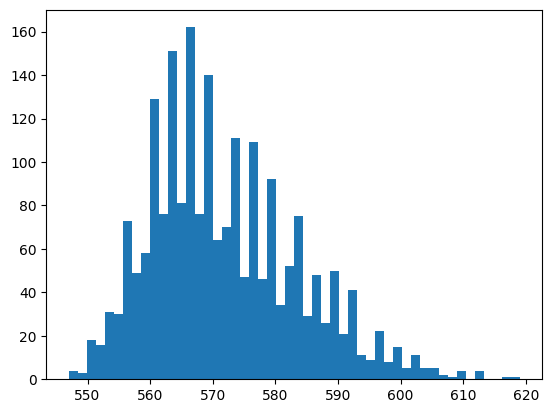

Max prompt length: 619
Max label length: 2


In [ ]:
# Find the max_length for tokenization to avoid wasting computing.
utils.find_max_length(scitail_test_few_shot, tokenizer=tokenizer, dataset_type=global_params['dataset_type'], examples=prompt_examples)

In [69]:
prompt_lengths, _ = utils.get_lengths(scitail_test_few_shot, tokenizer, global_params['dataset_type'], examples=prompt_examples)
df = pd.DataFrame(prompt_lengths, columns=["length"])
tokens = 619 # Max length to check
n = (df["length"] > tokens).sum() # Number of prompts with # > tokens
percent = round(n/len(df)*100, 3)
print(f"Number of examples that have over {tokens} tokens and will be truncated: {n} out of {len(df)} examples or {percent}%")

Number of examples that have over 619 tokens and will be truncated: 0 out of 2116 examples or 0.0%


In [ ]:
# Define dataset and create a dataloader.
dataset_test = utils.MyDataset_few_shot(dataframe=scitail_test_few_shot,
                                        examples=prompt_examples,
                                        tokenizer=tokenizer,
                                        dataset_type=global_params['dataset_type'],
                                        prompt_max_length=619,
                                        label_max_length=2)

batch_size = 16 # Change batch size according to GPU
dataloader = DataLoader(dataset_test, batch_size=batch_size, shuffle=False)

In [71]:
# Show an example prompt
print(dataset_test[0]['prompt'])

Examples:
Example 1
Premise: Most of the volume of the universe is in the electrodynamic plasma state.
Hypothesis: Plasma matter makes up most of the universe.
Answer: entails 

Example 2
Premise: Even in the 50- to 60-year age-at-onset group, the most common early-onset etiology involves the inheritance of one or more apolipoprotein E epsilon4 alleles as susceptibility genes and not autosomal dominant mutations.
Hypothesis: A person affected by an autosomal dominant disorder has one mutated allele.
Answer: neutral 

Example 3
Premise: She started to test samples of different metals and ores to note the length of time it took for samples to discharge an electroscope.
Hypothesis: Metals start out as ore.
Answer: neutral 

Example 4
Premise: The hale formed by the impact is about 200 meters deep.
Hypothesis: The photic zone extends 200 meters deep.
Answer: neutral 

Example 5
Premise: Identify characteristics of water quality and flow in Barton Springs and the Edwards Aquifer.
Hypothesis

In [ ]:
# Test
predictions, gold_labels, batch_probs = utils.test_run(model=model,
                                          dataloader=dataloader,
                                          tokenizer=tokenizer,
                                          dataset_type=global_params['dataset_type'])

for i, pair in enumerate(zip(predictions, gold_labels)):
    print(pair, batch_probs[i])

neutral
neutral
neutral
entailment


In [ ]:
from tqdm import tqdm

# Load checkpoint if it exists
predicted_labels, gold_labels, start_batch = utils.load_checkpoint(checkpoint_path=checkpoint_path)
labels = utils.get_labels('scitail')

# Loop over the batches
with torch.no_grad():
    for i, batch in enumerate(tqdm(dataloader, desc="Evaluating", unit="batch")):

        # Continue from last checkpoint
        if i < start_batch:
            continue

        input_ids_batch = batch["input_ids"].to(model.device) # Move to GPU
        attention_mask_batch = batch["attention_mask"].to(model.device) # Move to GPU
        gold_labels_batch = batch["labels"] # Keep to CPU

        batch_probs = utils.get_model_probs(batch_input_ids=input_ids_batch,
                                      batch_attention_mask=attention_mask_batch,
                                      dataset_type=global_params['dataset_type'],
                                      model=model,
                                      tokenizer=tokenizer)

        batch_pred_indices = torch.argmax(batch_probs, dim=1)
        batch_pred_labels = [labels[i] for i in batch_pred_indices]

        predicted_labels.extend(batch_pred_labels)
        gold_labels.extend(gold_labels_batch)

        # Save checkpoint
        if i % 50 == 0 or i == len(dataloader) - 1:
            torch.save({"predicted_labels": predicted_labels,
                        "gold_labels": gold_labels,
                        "batch_no": i+1}, checkpoint_path)

            print(f"Checkpoint saved: {i+1}, {checkpoint_path}")

Checkpoint found.
Accuracy: 0.7547.
 F1 Score: 0.7249.
 Matthew's Correlation Coefficient: 0.4765.
 Cohen's Kappa Score: 0.4588.


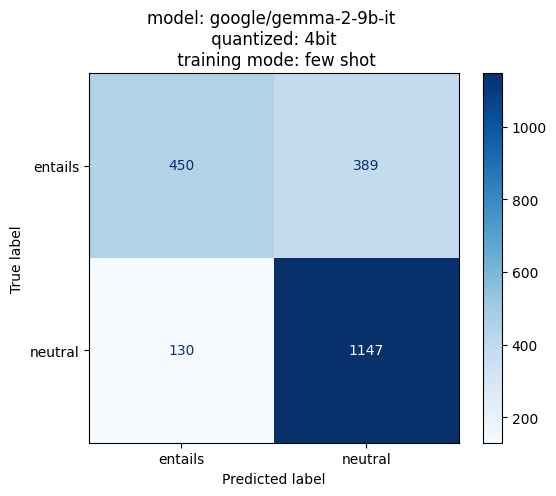

In [ ]:
# Calculate metrics
predicted_labels, gold_labels, _ = utils.load_checkpoint(checkpoint_path)
utils.evaluate_metrics(predicted_labels=predicted_labels, gold_labels=gold_labels, params=global_params)